# Box Plots

Seasonal and Monthly Box Plots HCW Count and HCW Days

Contributions from Kelvin Hawthorne and Caitlin Roufa

In [1]:
# import packages
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import pandas as pd
import glob
import numpy as np
from scipy.ndimage import gaussian_filter1d

In [2]:
# set file paths
paths = {
    "HIST": '/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*.csv',
    "MID4.5": '/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*.csv',
    "MID8.5": '/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*.csv',
    "END4.5": '/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*.csv',
    "END8.5": '/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*.csv',
}

In [3]:
# custom color table and plot styles
colors = {
    "HIST": '#c7e9c0',
    "MID4.5": '#6baed6',
    "MID8.5": '#af0f15',
    "END4.5": '#6baed6',
    "END8.5": '#af0f15',

}

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in colors.items()]

hatch_styles = {
    "END4.5": "///////",  
    "END8.5": "///////"
}

order = ["HIST", "MID4.5", "MID8.5", "END4.5", "END8.5"]
mpl.rcParams['hatch.linewidth'] = 0.5

legend_handles = []

for label in order:
    color = colors[label]
    if label in hatch_styles:
        patch = mpatches.Patch(facecolor=color, edgecolor="black", hatch=hatch_styles[label], label=label)
    else:
        patch = mpatches.Patch(facecolor=color, label=label)
    
    legend_handles.append(patch)

In [4]:
# define seasons
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    elif month in [9, 10, 11]:
        return 'SON'

In [5]:
# define seasons
seasons = ['DJF', 'MAM', 'JJA', 'SON']
data_for_plotting = {season: [] for season in seasons}
median_values = {name: [] for name in paths}

In [6]:
# read in data, threshold, and set datetime
for name, path in paths.items():
    # Read and concatenate all matching files for the current path
    data_frames = [pd.read_csv(file) for file in glob.glob(path)]
    data = pd.concat(data_frames)
    data = data[(data['UVV'] >= 25) & (data['DBZ'] >= 40)]


    # Convert 'Time' column to datetime, extract year and month
    data['Year'] = pd.to_datetime(data['Time']).dt.year
    data['Month'] = pd.to_datetime(data['Time']).dt.month
    data['Season'] = data['Month'].apply(month_to_season)

    # Append data for each season
    for season in seasons:
        season_data = data[data['Season'] == season]['Year'].value_counts()
        data_for_plotting[season].append((name, season_data))
        
#Defining properties of the fliers and mean points
meanpointprops = dict(marker='.', markeredgecolor='black',
                      markerfacecolor='black', markersize=2)
fliercircleprops  = dict(marker="o", markersize=4)

### Seasonal Plot

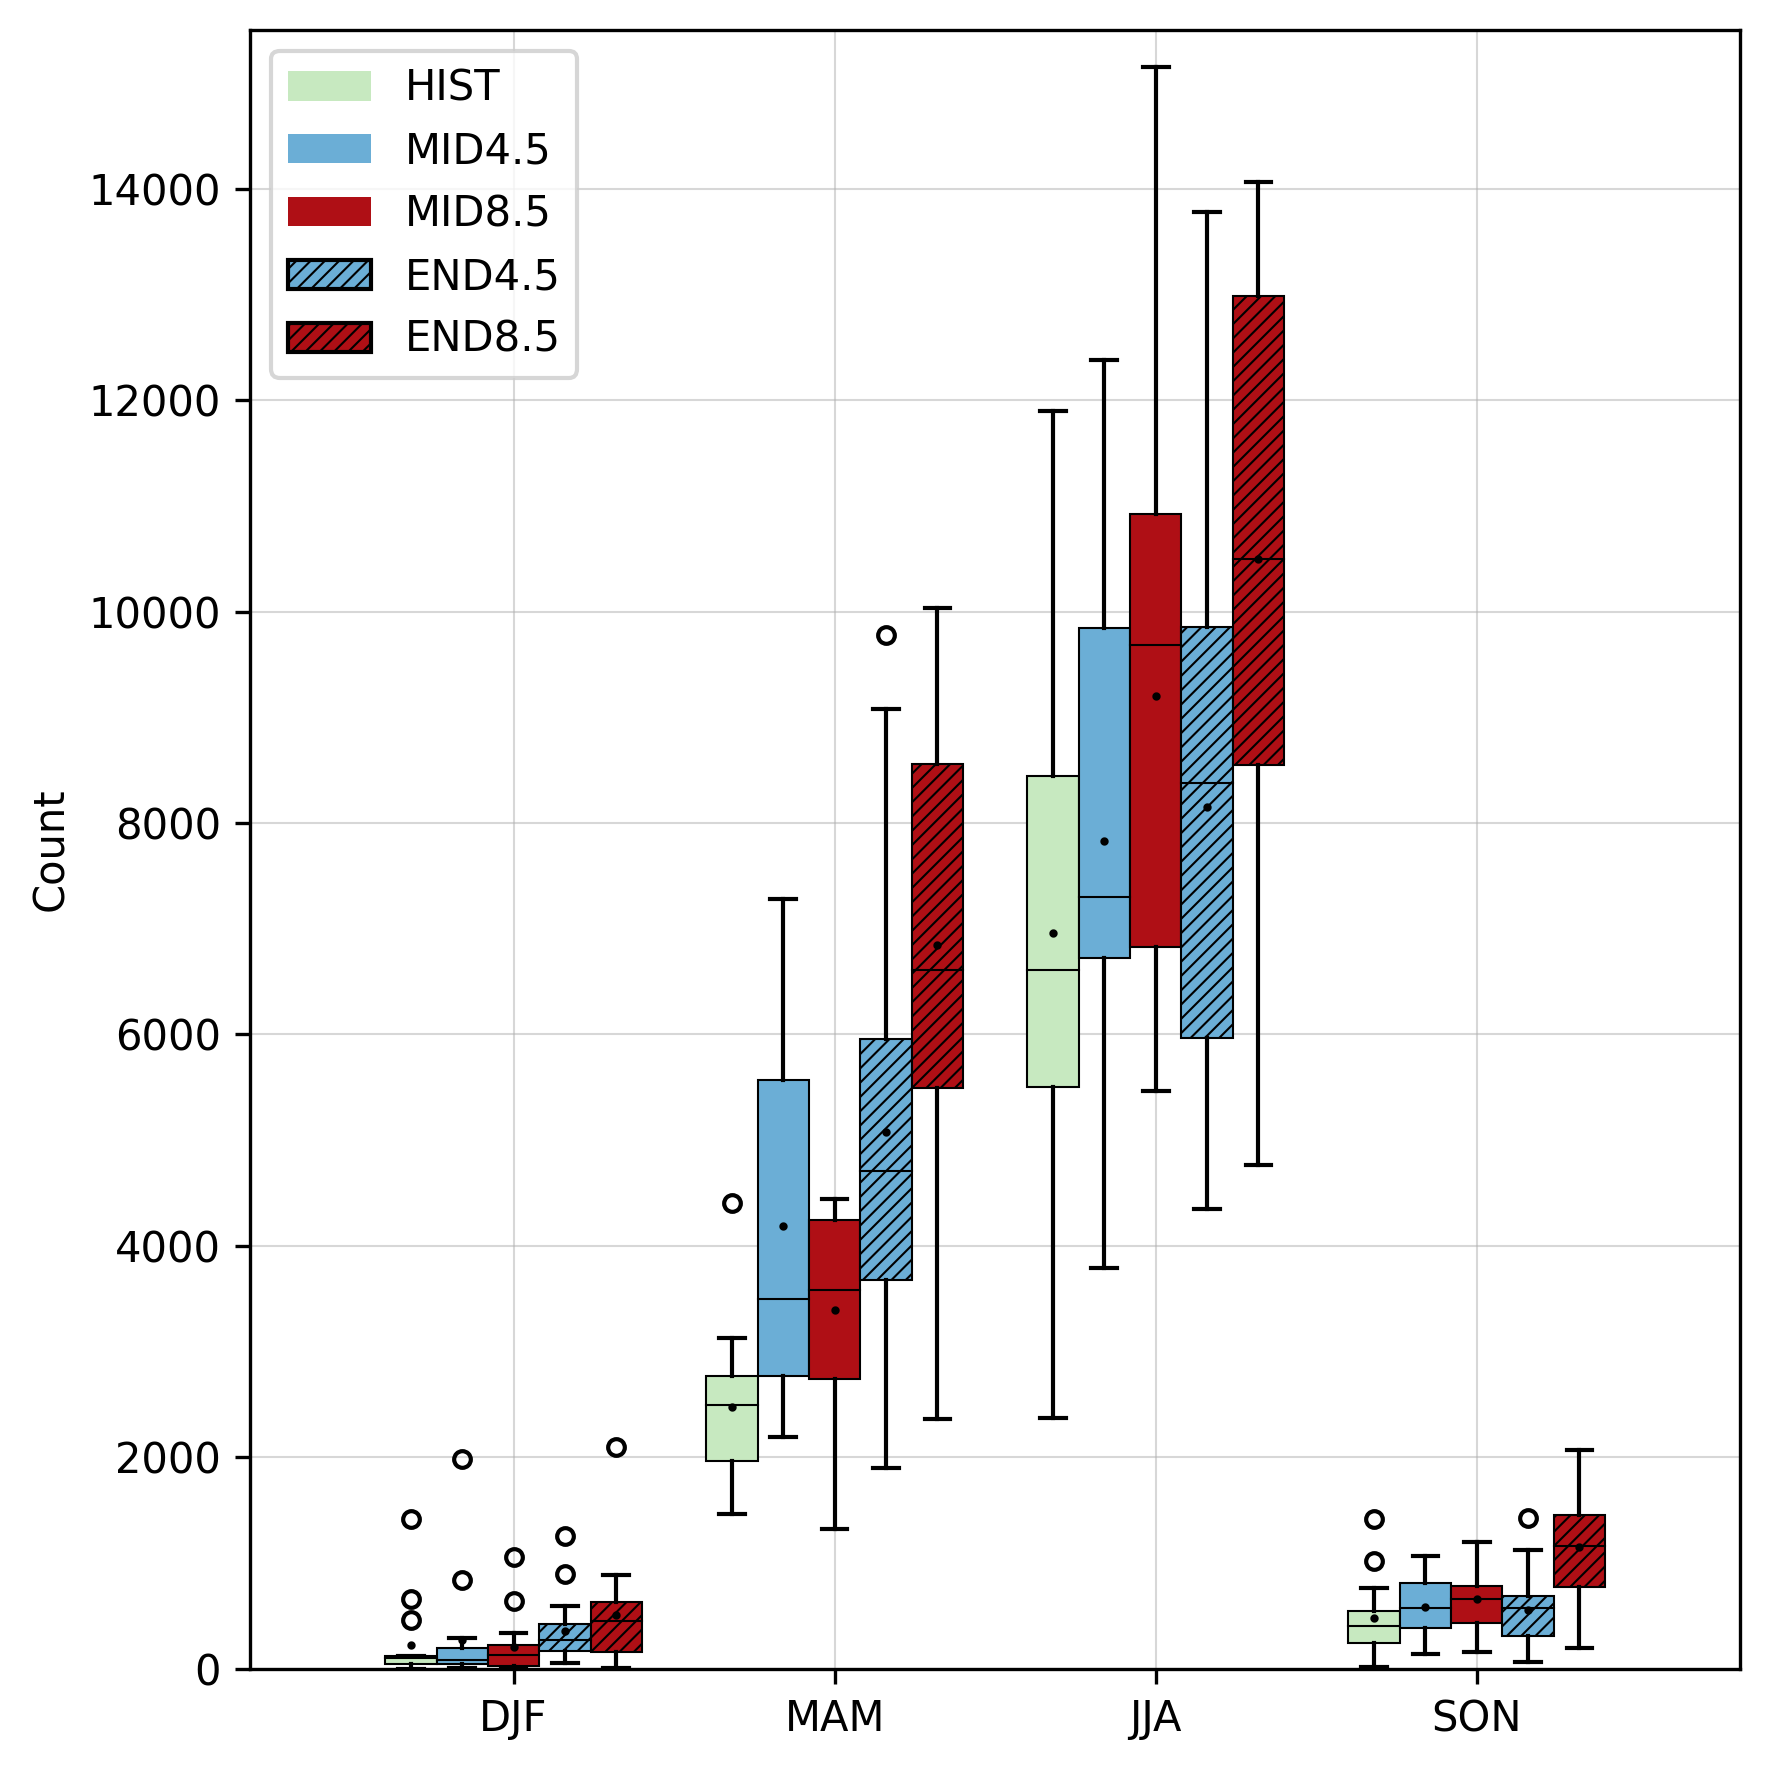

In [7]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Plot data grouped by season
width = 0.16  # width of the box plots
median_positions = []  # Initialize empty list to store median positions and values
median_value = np.median(season_data)
for idx, season in enumerate(seasons):
    for j, name in enumerate(paths):  # Ensure the order is based on the paths dictionary
        season_data = next((data for n, data in data_for_plotting[season] if n == name), pd.Series(dtype=float))  # Specify dtype explicitly
        if not season_data.empty:
            position = idx - (len(data_for_plotting[season]) - 1) * width / 2 + j * width
            median_positions.append((position, np.median(season_data)))  # Store positions for the trend line
            box = ax.boxplot(season_data, positions=[position], widths=width, boxprops=dict(linewidth=0.50), patch_artist=True, showfliers=True, flierprops=fliercircleprops, showmeans=True, meanprops=meanpointprops)
            for patch in box['boxes']:
                patch.set_facecolor(colors[name])
                median_positions.append((position, median_value))
                if name in hatch_styles:
                    patch.set_hatch(hatch_styles[name])
                for median in box['medians']:
                    median.set_color('black')
                    median.set_linewidth(0.50)

# if median_positions:
#     x, y = zip(*sorted(median_positions, key=lambda mp: mp[0]))  # Sort by position to avoid undesired lines
#     ax.plot(x, y, '', color='black', label='Overall Median Trend')

# width = 0.15  # width of the box plots
# for idx, season in enumerate(seasons):
#     for j, (name, data) in enumerate(data_for_plotting[season]):
#         if not data.empty:
#             # Position each dataset within the group for the current season
#             position = idx - (len(data_for_plotting[season]) - 1) * width / 2 + j * width
            
#             box = ax.boxplot(data, positions=[position], widths=width, patch_artist=True, showfliers=False)
            
#             for patch in box['boxes']:
#                 patch.set_facecolor(colors[name])  # Set the color for each box plot based on the dataset
                
#             for median in box['medians']:
#                 median.set_color('black')
#                 median.set_linewidth(2)
                
#             q1 = np.percentile(data, 25)
#             q3 = np.percentile(data, 75)
#             iqr = q3 - q1
#             lower_whisker = q1 - 1.5 * iqr
#             upper_whisker = q3 + 1.5 * iqr

#             # Define low and high outliers as min and max values within the data outside whiskers
#             low_outlier = data[data < lower_whisker].min()
#             high_outlier = data[data > upper_whisker].max()
            
#             if not np.isnan(low_outlier):
#                 ax.scatter(position, low_outlier, color='blue', zorder=3)  # Plot low outlier in blue
#             if not np.isnan(high_outlier):
#                 ax.scatter(position, high_outlier, color='red', zorder=3)  # Plot high outlier in red

# ax.set_title('Seasonal SCW Counts')
ax.set_ylabel('Count')
# ax.set_xlabel('Season')
ax.set_xticks(np.arange(len(seasons)))
ax.set_xticklabels(seasons)
ax.legend(handles=legend_handles, title="", loc='upper left')
ax.set_ylim(0,15500)

plt.tight_layout()
plt.margins(0,0)
plt.grid(lw=0.5, alpha=0.5, zorder=0.1)

plt.savefig('../Plots/Botplot_Seasonal_Count.png',format='png', dpi=500, bbox_inches="tight")

plt.show()

### Monthly Plots

Running the following cells will cause the previous plot to not run correctly unless you restart the kernel.

In [8]:
# read and process files
data_for_plotting = {month: [] for month in range(12)}  # dictionary storage for months

for name, path in paths.items():
    data_frames = [pd.read_csv(file) for file in glob.glob(path)]
    data = pd.concat(data_frames)
    data = data[(data['UVV'] >= 25) & (data['DBZ'] >= 40)]
    data['Year'] = pd.to_datetime(data['Time']).dt.year
    data['Month'] = pd.to_datetime(data['Time']).dt.month

    for month in range(1, 13):
        month_index = month - 1  # adjust month to zero index for array
        month_data = data[data['Month'] == month]['Year'].value_counts()
        data_for_plotting[month_index].append((name, month_data))

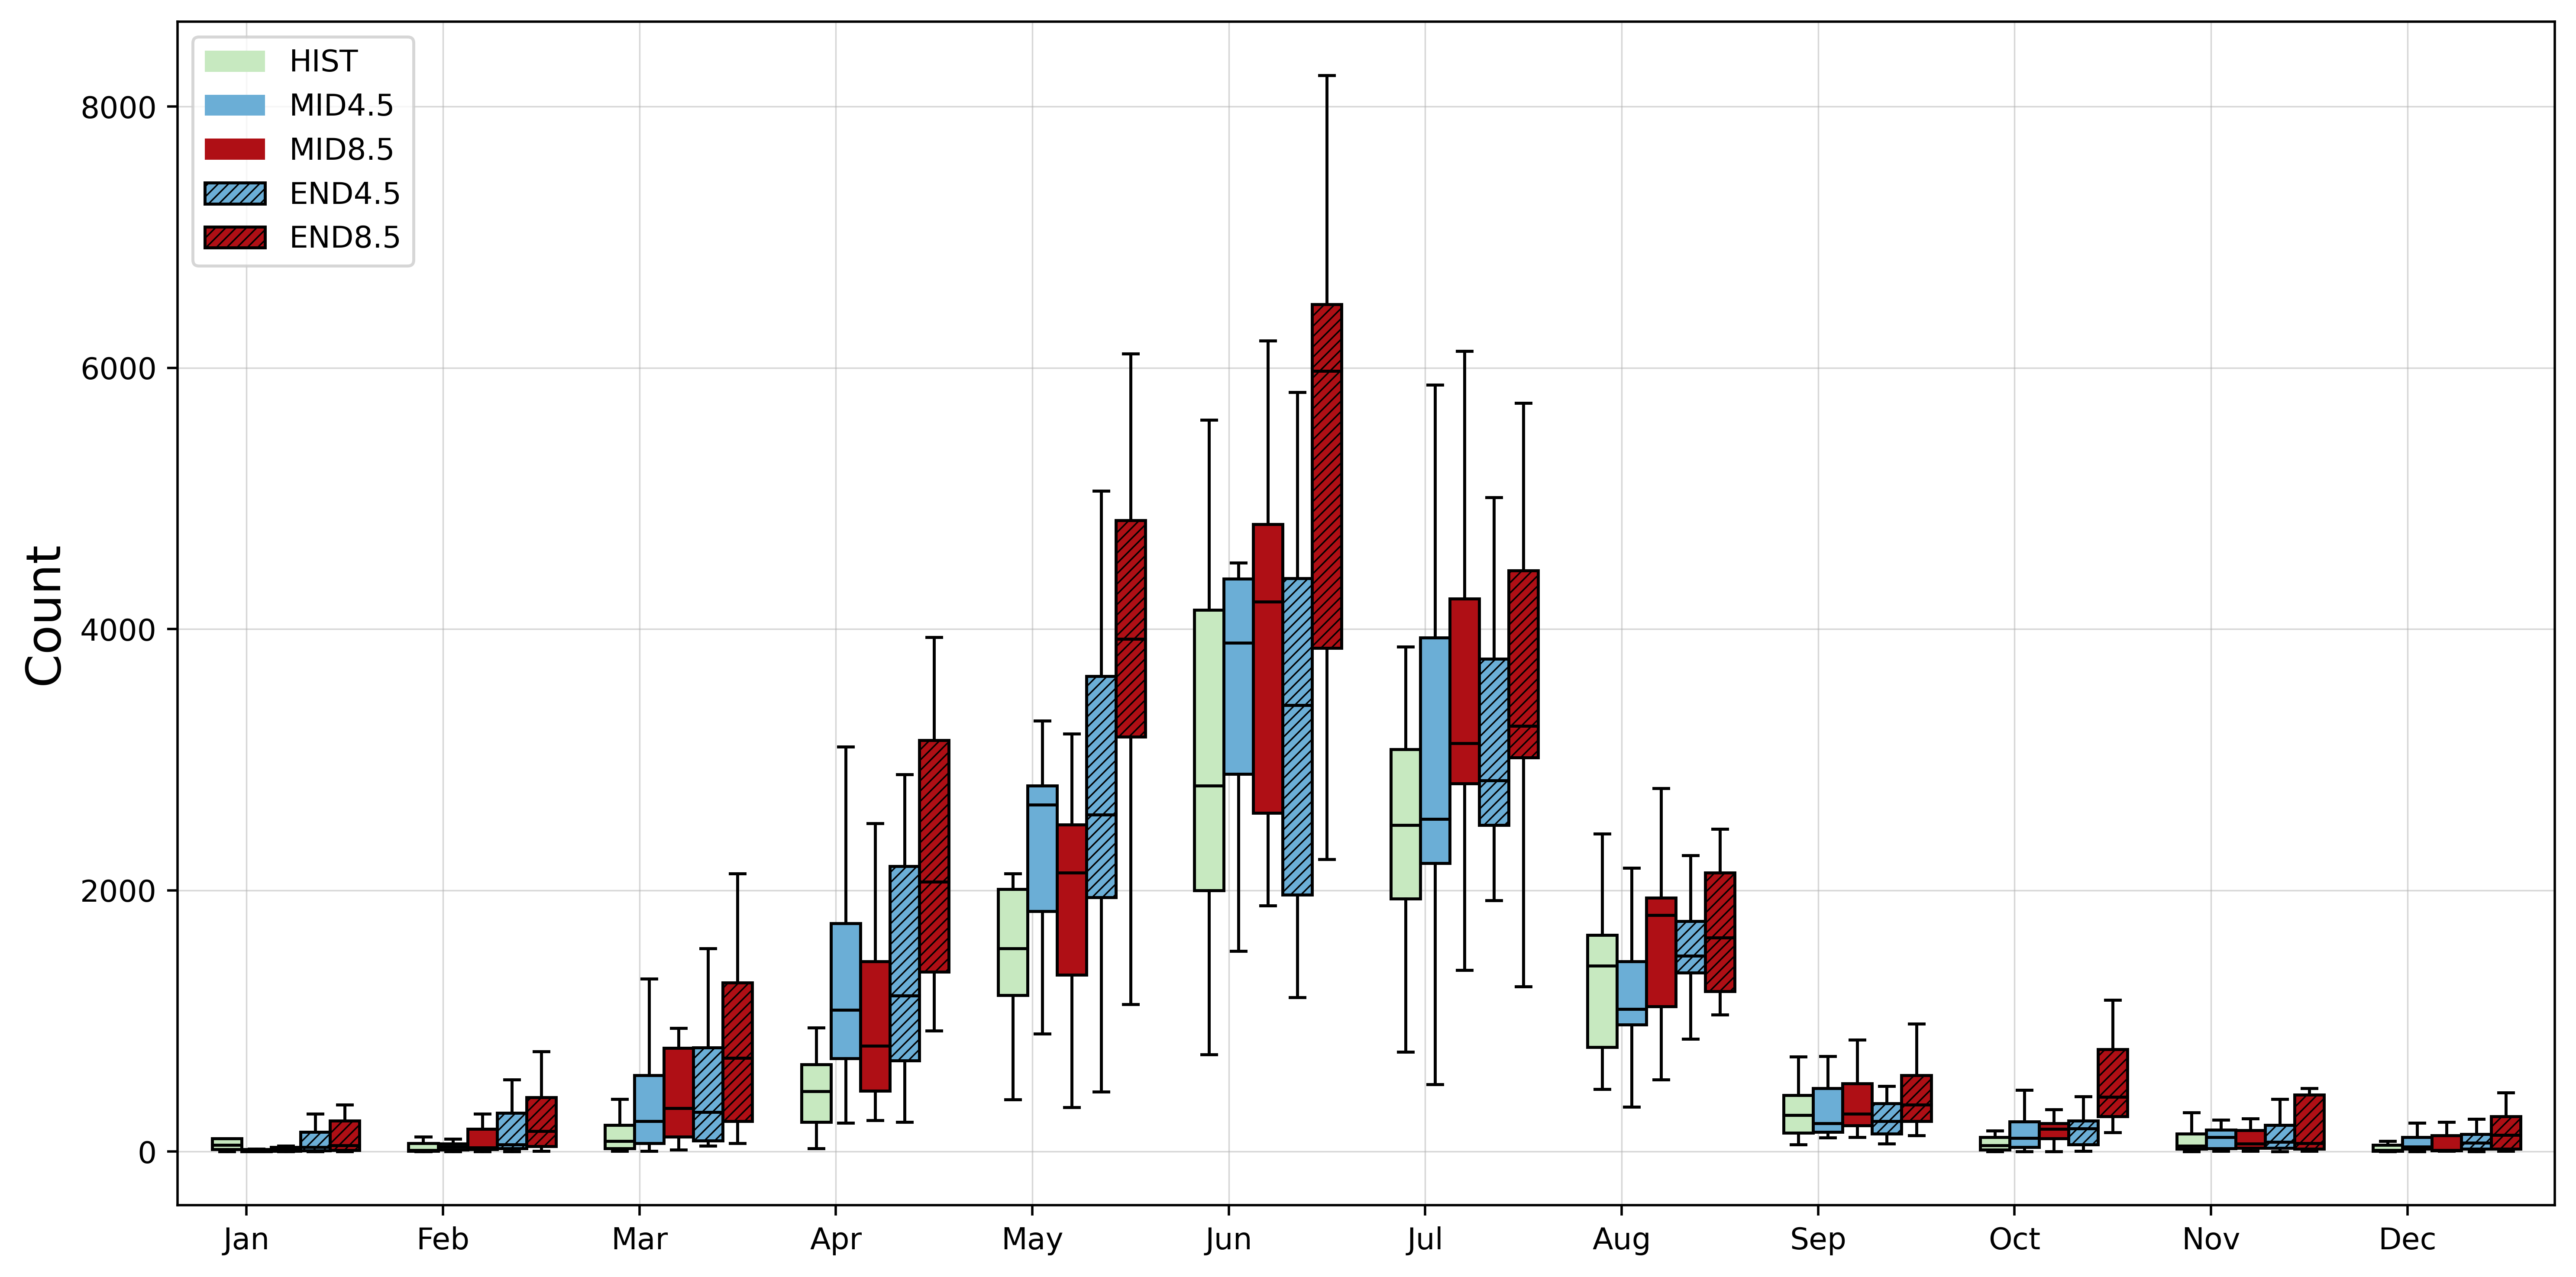

In [9]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=500)
width = 0.3  # Box plot width

for idx, month in enumerate(range(12)):
        base_position = idx * 2  # Increase the base increment to avoid overlap
        for j, (name, data) in enumerate(data_for_plotting[month]):
            position = base_position + j * width  # Adjust position calculation
            box = ax.boxplot(data, positions=[position], widths=width, patch_artist=True, showfliers=False)
            box['boxes'][0].set_facecolor(colors[name])
            box['medians'][0].set_color('black')
            box['medians'][0].set_linewidth(2)
            for patch in box['boxes']:
                patch.set_facecolor(colors[name])
                median_positions.append((position, median_value))
                if name in hatch_styles:
                    patch.set_hatch(hatch_styles[name])
                for median in box['medians']:
                    median.set_color('black')
                    median.set_linewidth(1)


# ax.set_title('Monthly SCW Counts', fontsize=30).set_weight('bold')
ax.set_ylabel('Count', fontsize=16)
# ax.set_xlabel('Month', fontsize=20).set_weight('bold')
ax.set_xticks([i * 2 + 0.2 for i in range(12)])  # Center ticks between groups
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(handles=legend_handles, loc='upper left')
plt.tight_layout()
plt.grid(lw=0.5, alpha=0.5)

plt.savefig('../Plots/BoxPlot_Monthly_Count.png', format='png', dpi=500, bbox_inches="tight")

plt.show()

In [24]:
# warm and cool season function and definitions
def month_to_season(month):
    if month in [3, 4, 5, 6, 7, 8]:
        return 'Warm'
    elif month in [9, 10, 11, 12, 1, 2]:
        return 'Cool' 

warmcools = ['Warm', 'Cool']
warmcool_data = {warmcool: [] for warmcool in warmcools}
data_for_plotting = {i: [] for i in range(4, 10)}  # data for months April through September

In [25]:
# function to process and filter data for warm or cool season
def process_data(season, month_range):
    data_for_plotting = {i: [] for i in month_range}  # dict for selected months

    for name, path in paths.items():
        # read and concatenate matching files for current path
        data_frames = [pd.read_csv(file) for file in glob.glob(path)]
        data = pd.concat(data_frames)
        data = data[(data['UVV'] >= 25) & (data['DBZ'] >= 40)]

        # convert to datetime and extract yr and mth
        data['Year'] = pd.to_datetime(data['Time']).dt.year
        data['Month'] = pd.to_datetime(data['Time']).dt.month
        data['Season'] = data['Month'].apply(month_to_season)

        # filter data by season
        data = data[data['Season'] == season]

        # append data for each month in selected range
        for month in month_range:
            monthly_data = data[data['Month'] == month]['Year'].value_counts()
            data_for_plotting[month].append((name, monthly_data))

    return data_for_plotting

In [26]:
# plotting function
def plot_season_data(season, month_range, month_labels, title):
    data_for_plotting = process_data(season, month_range)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    width = 0.23  # Box plot width

    for idx, month in enumerate(month_range):  # plot data for each month in range
        base_position = idx * 2  # inc base increment to avoid overlap
        for j, (name, data) in enumerate(data_for_plotting[month]):
            position = base_position + j * width  # adjust position calc
            box = ax.boxplot(data, positions=[position], widths=width, patch_artist=True, showfliers=False)
            box['boxes'][0].set_facecolor(colors[name])
            box['medians'][0].set_color('black')
            box['medians'][0].set_linewidth(2)
            for patch in box['boxes']:
                patch.set_facecolor(colors[name])
                median_positions.append((position, median_value))
                if name in hatch_styles:
                    patch.set_hatch(hatch_styles[name])
                for median in box['medians']:
                    median.set_color('black')
                    median.set_linewidth(1)

    ax.set_title(title, fontsize=20)
    ax.set_ylabel('Count', fontsize=16)
    # ax.set_xlabel('Month', fontsize=16).set_weight('bold')
    ax.set_xticks([i * 2 + 0.2 for i in range(len(month_range))])  # center ticks between groups
    ax.set_xticklabels(month_labels)
    ax.legend(handles=legend_handles, loc='upper left')
    plt.tight_layout()
    plt.grid(lw=0.5, alpha=0.5)

    plt.savefig(f'../Plots/BoxPlot_{season}_Season_Count.png', format='png', dpi=500, bbox_inches="tight")

    plt.show()

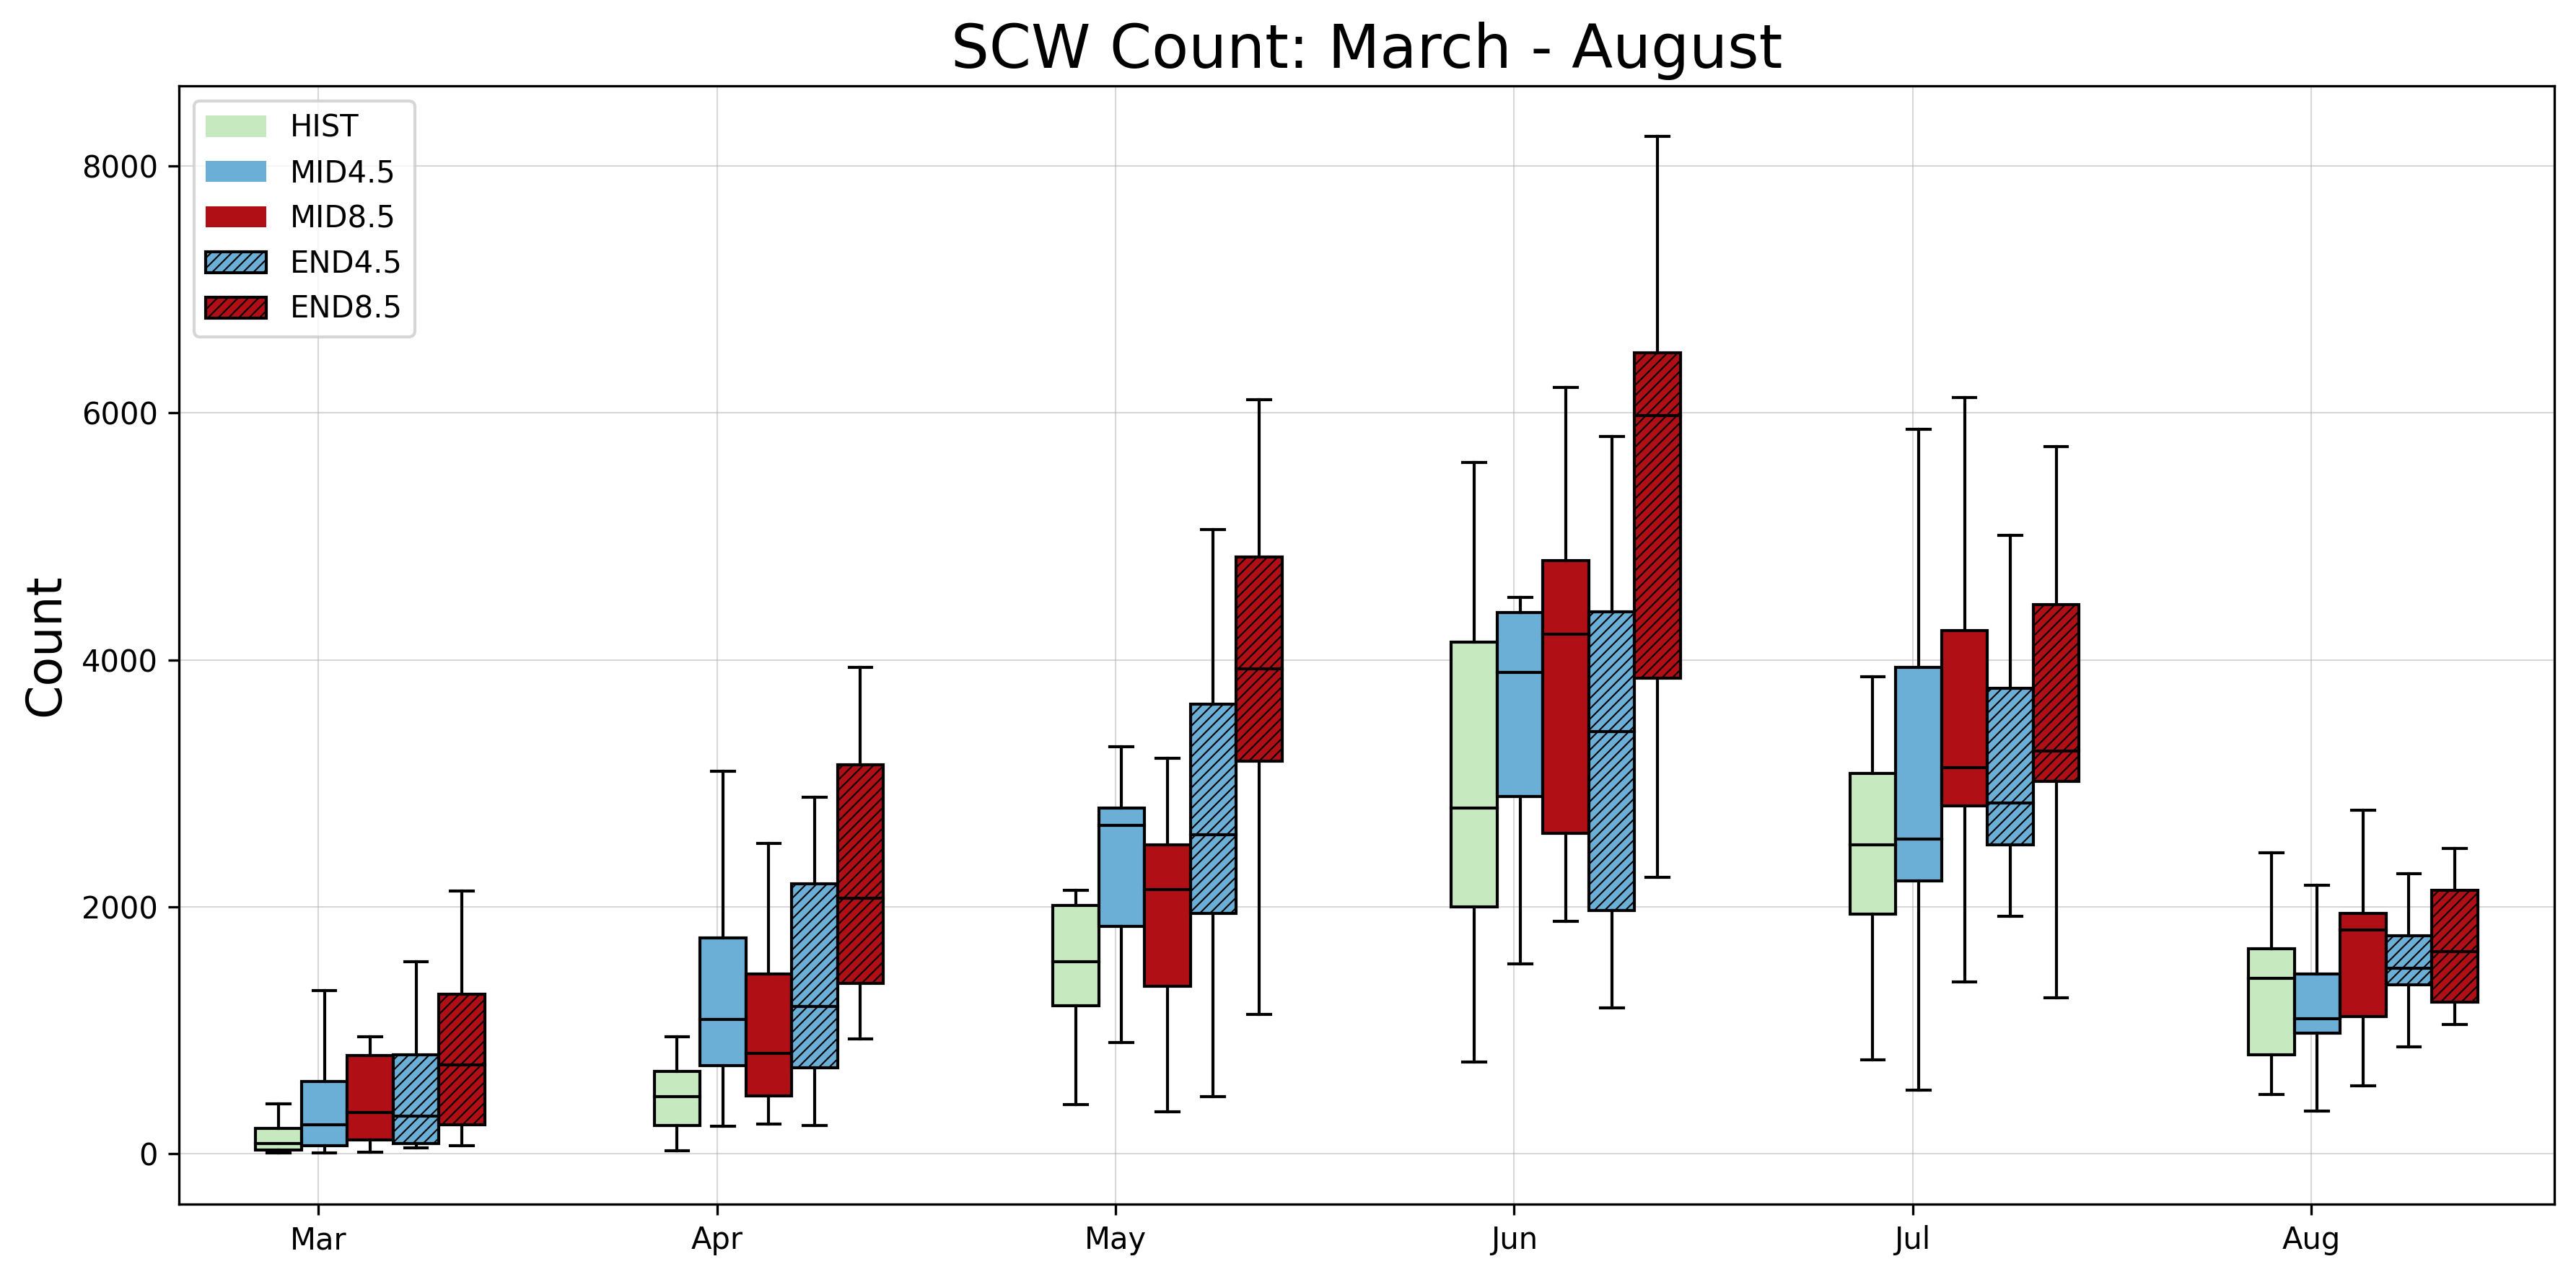

In [27]:
# "warm" season
plot_season_data(
    season='Warm',
    month_range=range(3, 9),  # March to August
    month_labels=['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'],
    title='SCW Count: March - August'
)

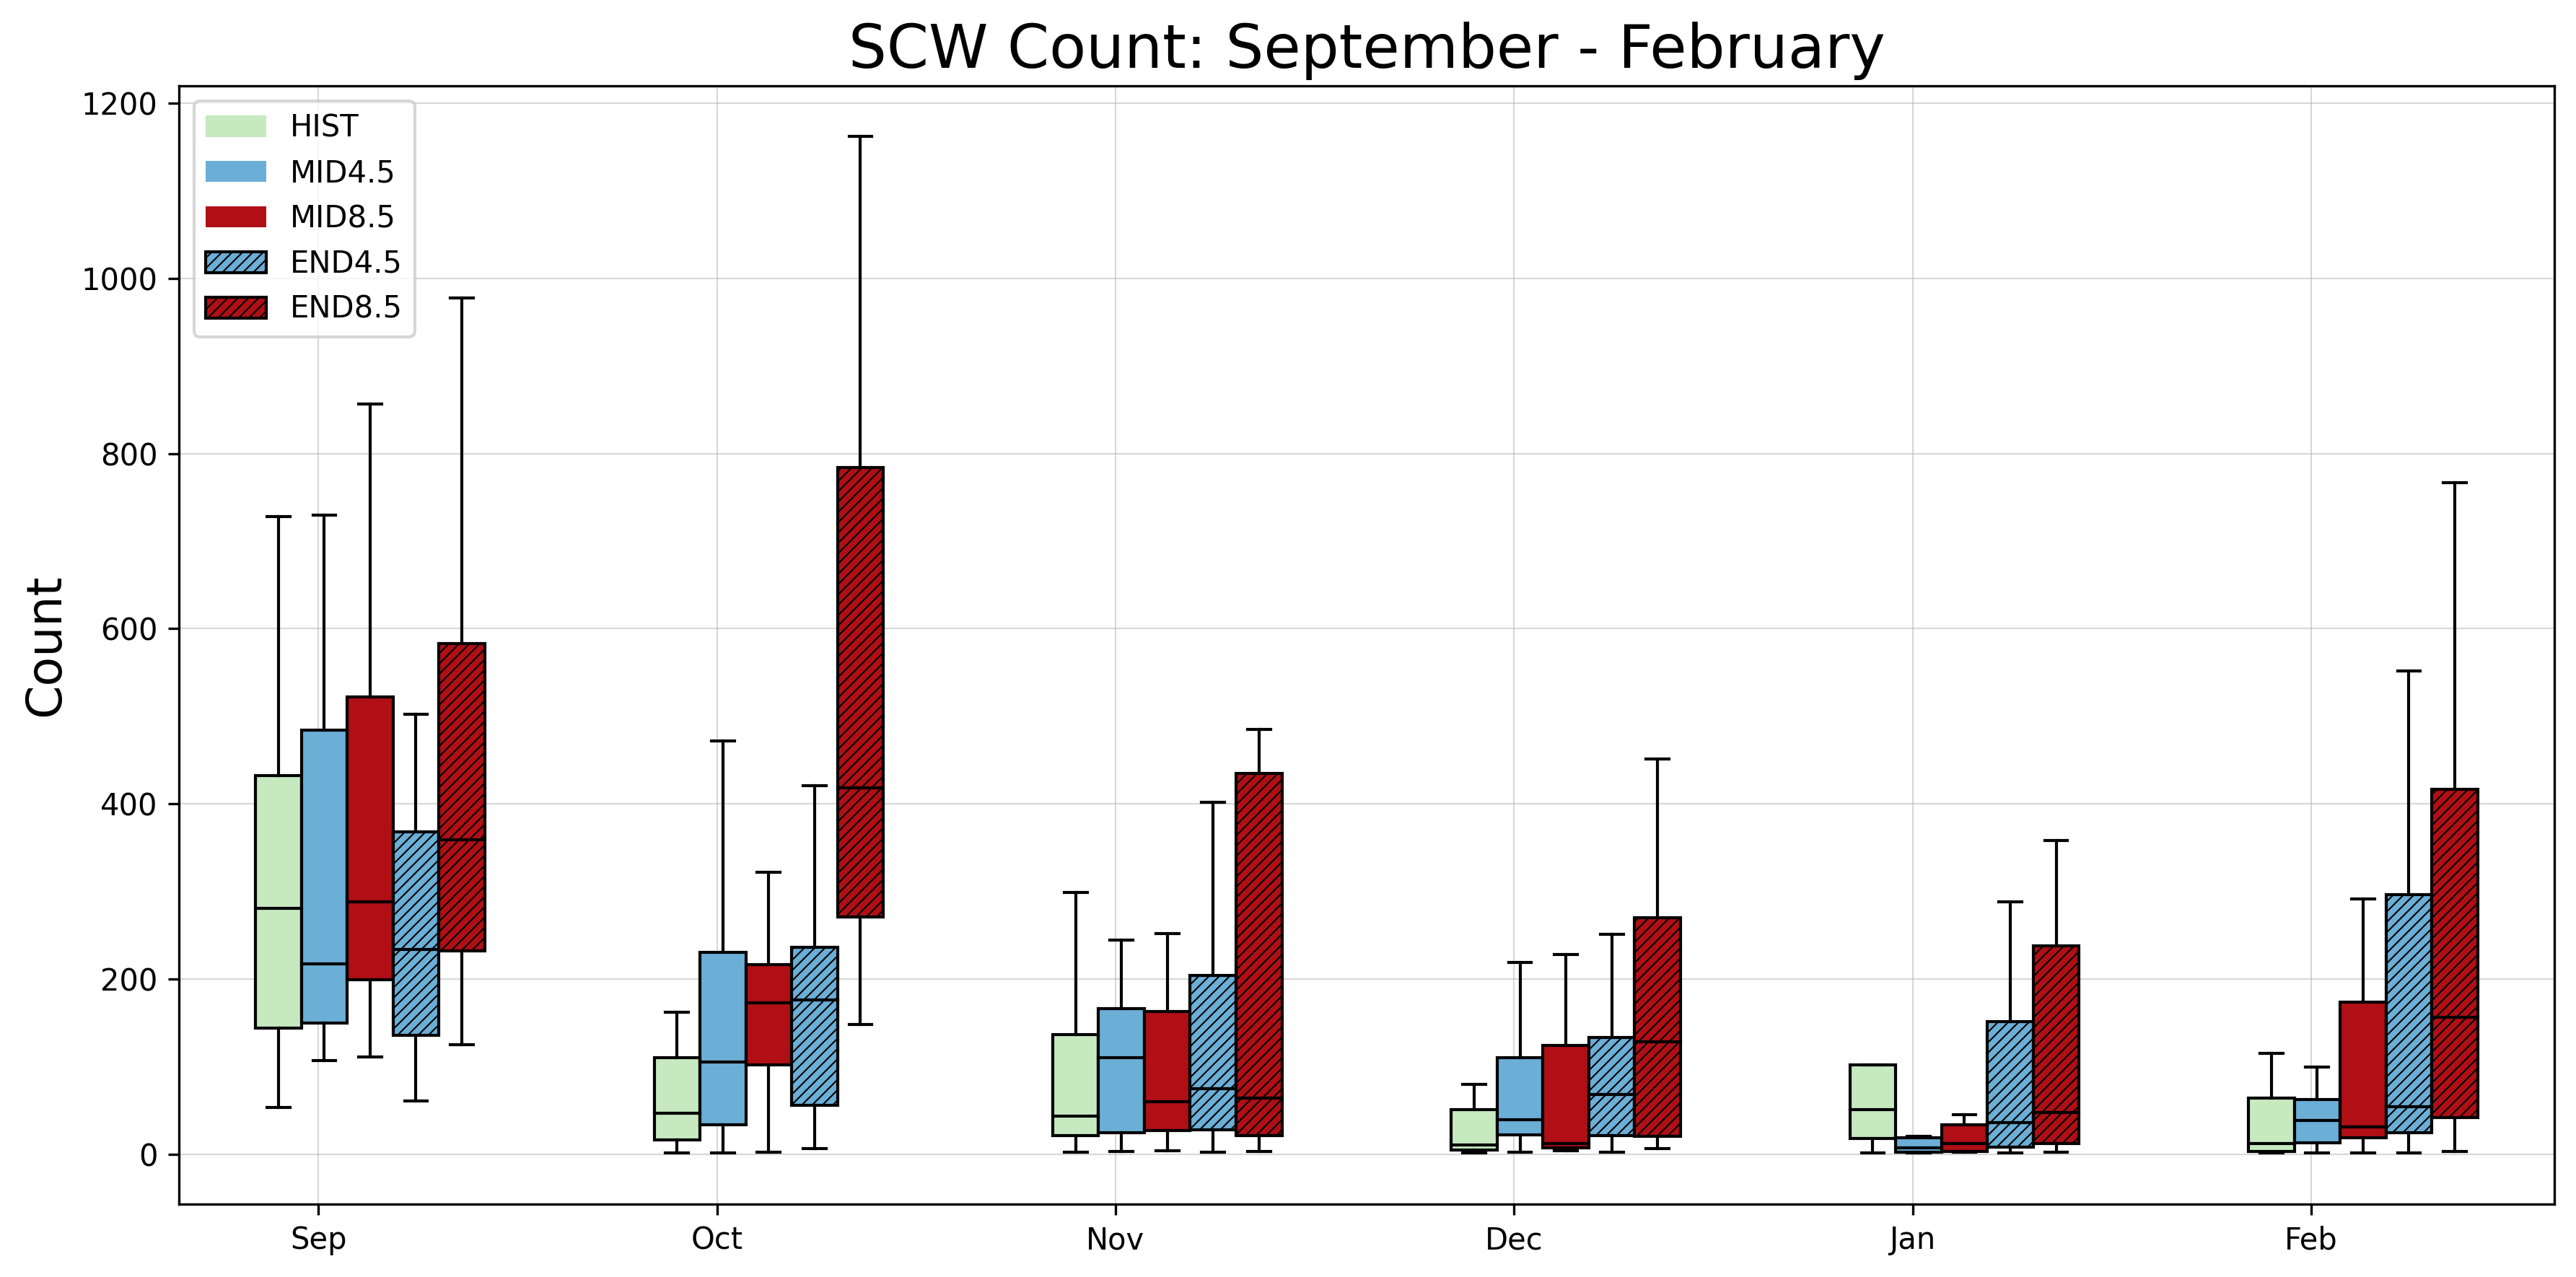

In [28]:
# "cool" season
plot_season_data(
    season='Cool',
    month_range=[9, 10, 11, 12, 1, 2],  # September to February
    month_labels=['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb'],
    title='SCW Count: September - February'
)